# Second practical work in Deep Learning course 
**Name:** Maha Kahla 


**Purpose of the laboratory work:** To study the process of object detection using Convolutional neural networks on the example of YOLO v11 architecture. 

To implement this practical work we need first to install a few new libraries: roboflow, so we can get a ready marked-up dataset from Roboflow Universe. ultralytics, so we can use YOLO architecture.

In [ ]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.2/84.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10


In [4]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.2/949.2 kB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 116.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 68.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

As usual we import necessary libraries that we might use during implementing our tasks

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import random
import sys
import time
from torchvision import datasets
import torch
import torchvision
import torchvision.transforms as T
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary
import os
from PIL import Image
from torch.utils.data import DataLoader

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


The following code we use to mount google drive so we can download dataset directly to drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd drive/My\ Drive/

/content/drive/My Drive


For the task of object detection we used the dataset "Fire and Smoke" from roboflow, it consists of 201 images. The dataset is divided into three parts where 141 images for training, 40 images for validation and 20 for testing. The following code is needed to download the dataset in YOLO format.

In [ ]:

from roboflow import Roboflow
rf = Roboflow(api_key="4GTQtrfCfm6vCRKfIAMN")
project = rf.workspace("roboflow-universe-projects").project("fire-and-smoke-segmentation")
version = project.version(4)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fire-and-Smoke-Segmentation-4 in yolov11:: 100%|██████████| 414/414 [00:03<00:00, 127.31it/s]


The next step is to load the pre-trained YOLO (You Only Look Once) model using the Ultralytics YOLOv11 framework in Python.

In [ ]:
# Loading a pre-trained model
model = YOLO('yolo11n.pt')  # 'n' - nano light version

We use the following line to train a YOLOv11 model using a custom dataset, this includes: Loading a YOLO model which is previously defined using model = YOLO('yolov11n.pt')), training the model using the dataset specified in the data.yaml file, runing training for 10 epochs, using images resized to 640×640 pixels for training and finally setting a batch size of 8.

In [ ]:
# Training of the model
results = model.train(data='/content/drive/MyDrive/datasets/Fire_and_Smoke/data.yaml', epochs=10, imgsz=640, batch=8)

New https://pypi.org/project/ultralytics/8.3.89 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.88 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/drive/MyDrive/datasets/Fire_and_Smoke/data.yaml, epochs=10, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train9, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=

100%|██████████| 755k/755k [00:00<00:00, 21.9MB/s]


Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics

train: Scanning /content/drive/MyDrive/datasets/Fire_and_Smoke/train/labels... 141 images, 0 backgrounds, 0 corrupt: 100%|██████████| 141/141 [00:01<00:00, 107.16it/s]


train: New cache created: /content/drive/MyDrive/datasets/Fire_and_Smoke/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


...

      10/10      1.49G      1.223      1.944      1.449         11        640: 100%|██████████| 18/18 [00:04<00:00,  4.29it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  6.33it/s]

                   all         40         97      0.691      0.607      0.616      0.376



10 epochs completed in 0.015 hours.
Optimizer stripped from runs/detect/train9/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train9/weights/best.pt, 5.5MB

Validating runs/detect/train9/weights/best.pt...
Ultralytics 8.3.88 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  3.04it/s]


                   all         40         97      0.691      0.607      0.616      0.376
                  fire         40         58      0.853      0.804      0.843      0.566
                 smoke         28         39      0.528       0.41      0.389      0.187
Speed: 0.3ms preprocess, 5.6ms inference, 0.0ms loss, 7.4ms postprocess per image
Results saved to runs/detect/train9


After the traning is finished we run evaluation using the validation dataset (as defined in data.yaml) and compute detection performance using mean Average Precision (mAP)which is the standard metric for object detection models. and finally we print key evaluation scores like mAP50 and mAP50-95.

In [ ]:
metrics = model.val()  # Evaluation on validation sample
print(metrics.box.map)  
print(metrics.box.map50)  

Ultralytics 8.3.88 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs


val: Scanning /content/drive/MyDrive/datasets/Fire_and_Smoke/valid/labels.cache... 40 images, 0 backgrounds, 0 corrupt: 100%|██████████| 40/40 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:02<00:00,  2.29it/s]


                   all         40         97      0.691      0.607      0.616      0.377
                  fire         40         58      0.854      0.804      0.842      0.567
                 smoke         28         39      0.529       0.41      0.389      0.188
Speed: 9.8ms preprocess, 10.0ms inference, 0.0ms loss, 9.0ms postprocess per image
Results saved to runs/detect/train92
0.37744285504185476
0.6156889794231659


As a result, the mean average precision at IoU 0.5 of detecting the fire is 84.2% which is considered very good since this patameter measures how well the model detects objects with at least 50% overlap between predictions and ground truth. Also the mean Average Precision averaged over IoU thresholds from 0.5 to 0.95 (mAP50-95) of detecting fire is 56.7%. we notice that this is a much stricter measure but this values is very good and reflect a strong model that works well for real-world applications. On the other hand, mAP50 for detecting smoke is only 38.9% which indicate poor performance that requires more training, better data, or a different model. 

Finally we test traind model with a new image as follows, the result is displayed in the image. 

In [11]:
from ultralytics import YOLO

# Load the trained model
model = YOLO('/content/drive/MyDrive/runs/detect/train9/weights/best.pt')  # Use best.pt after training


results = model.predict('/content/drive/MyDrive/datasets/im11.jpeg', save=True, imgsz=640, conf=0.5)


image 1/1 /content/drive/MyDrive/datasets/im11.jpeg: 448x640 1 fire, 1 smoke, 45.7ms
Speed: 2.2ms preprocess, 45.7ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)
Results saved to runs/detect/predict3


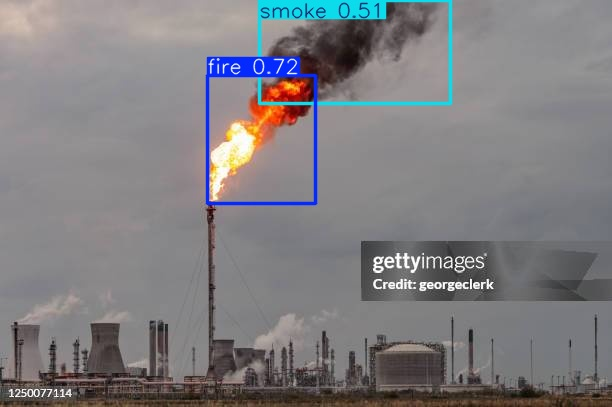

In [13]:
from IPython.display import display
from PIL import Image

image_path = "/content/drive/MyDrive/runs/detect/predict3/im11.jpg"  
display(Image.open(image_path))

We plot the results of the trainig, the PR graph shows the model detects fire very well, with high precision and recall, but struggles with detecting smoke, as precision and recall drop sharply. The model achieves moderate overall performance. 


this means: False positives (misclassifying non-smoke as smoke).
False negatives (failing to detect actual smoke).
as a final result, Fire detection is good, but smoke detection needs improvement.

Possible improvement could be: Increase training data for Smoke, improve data augmentation.

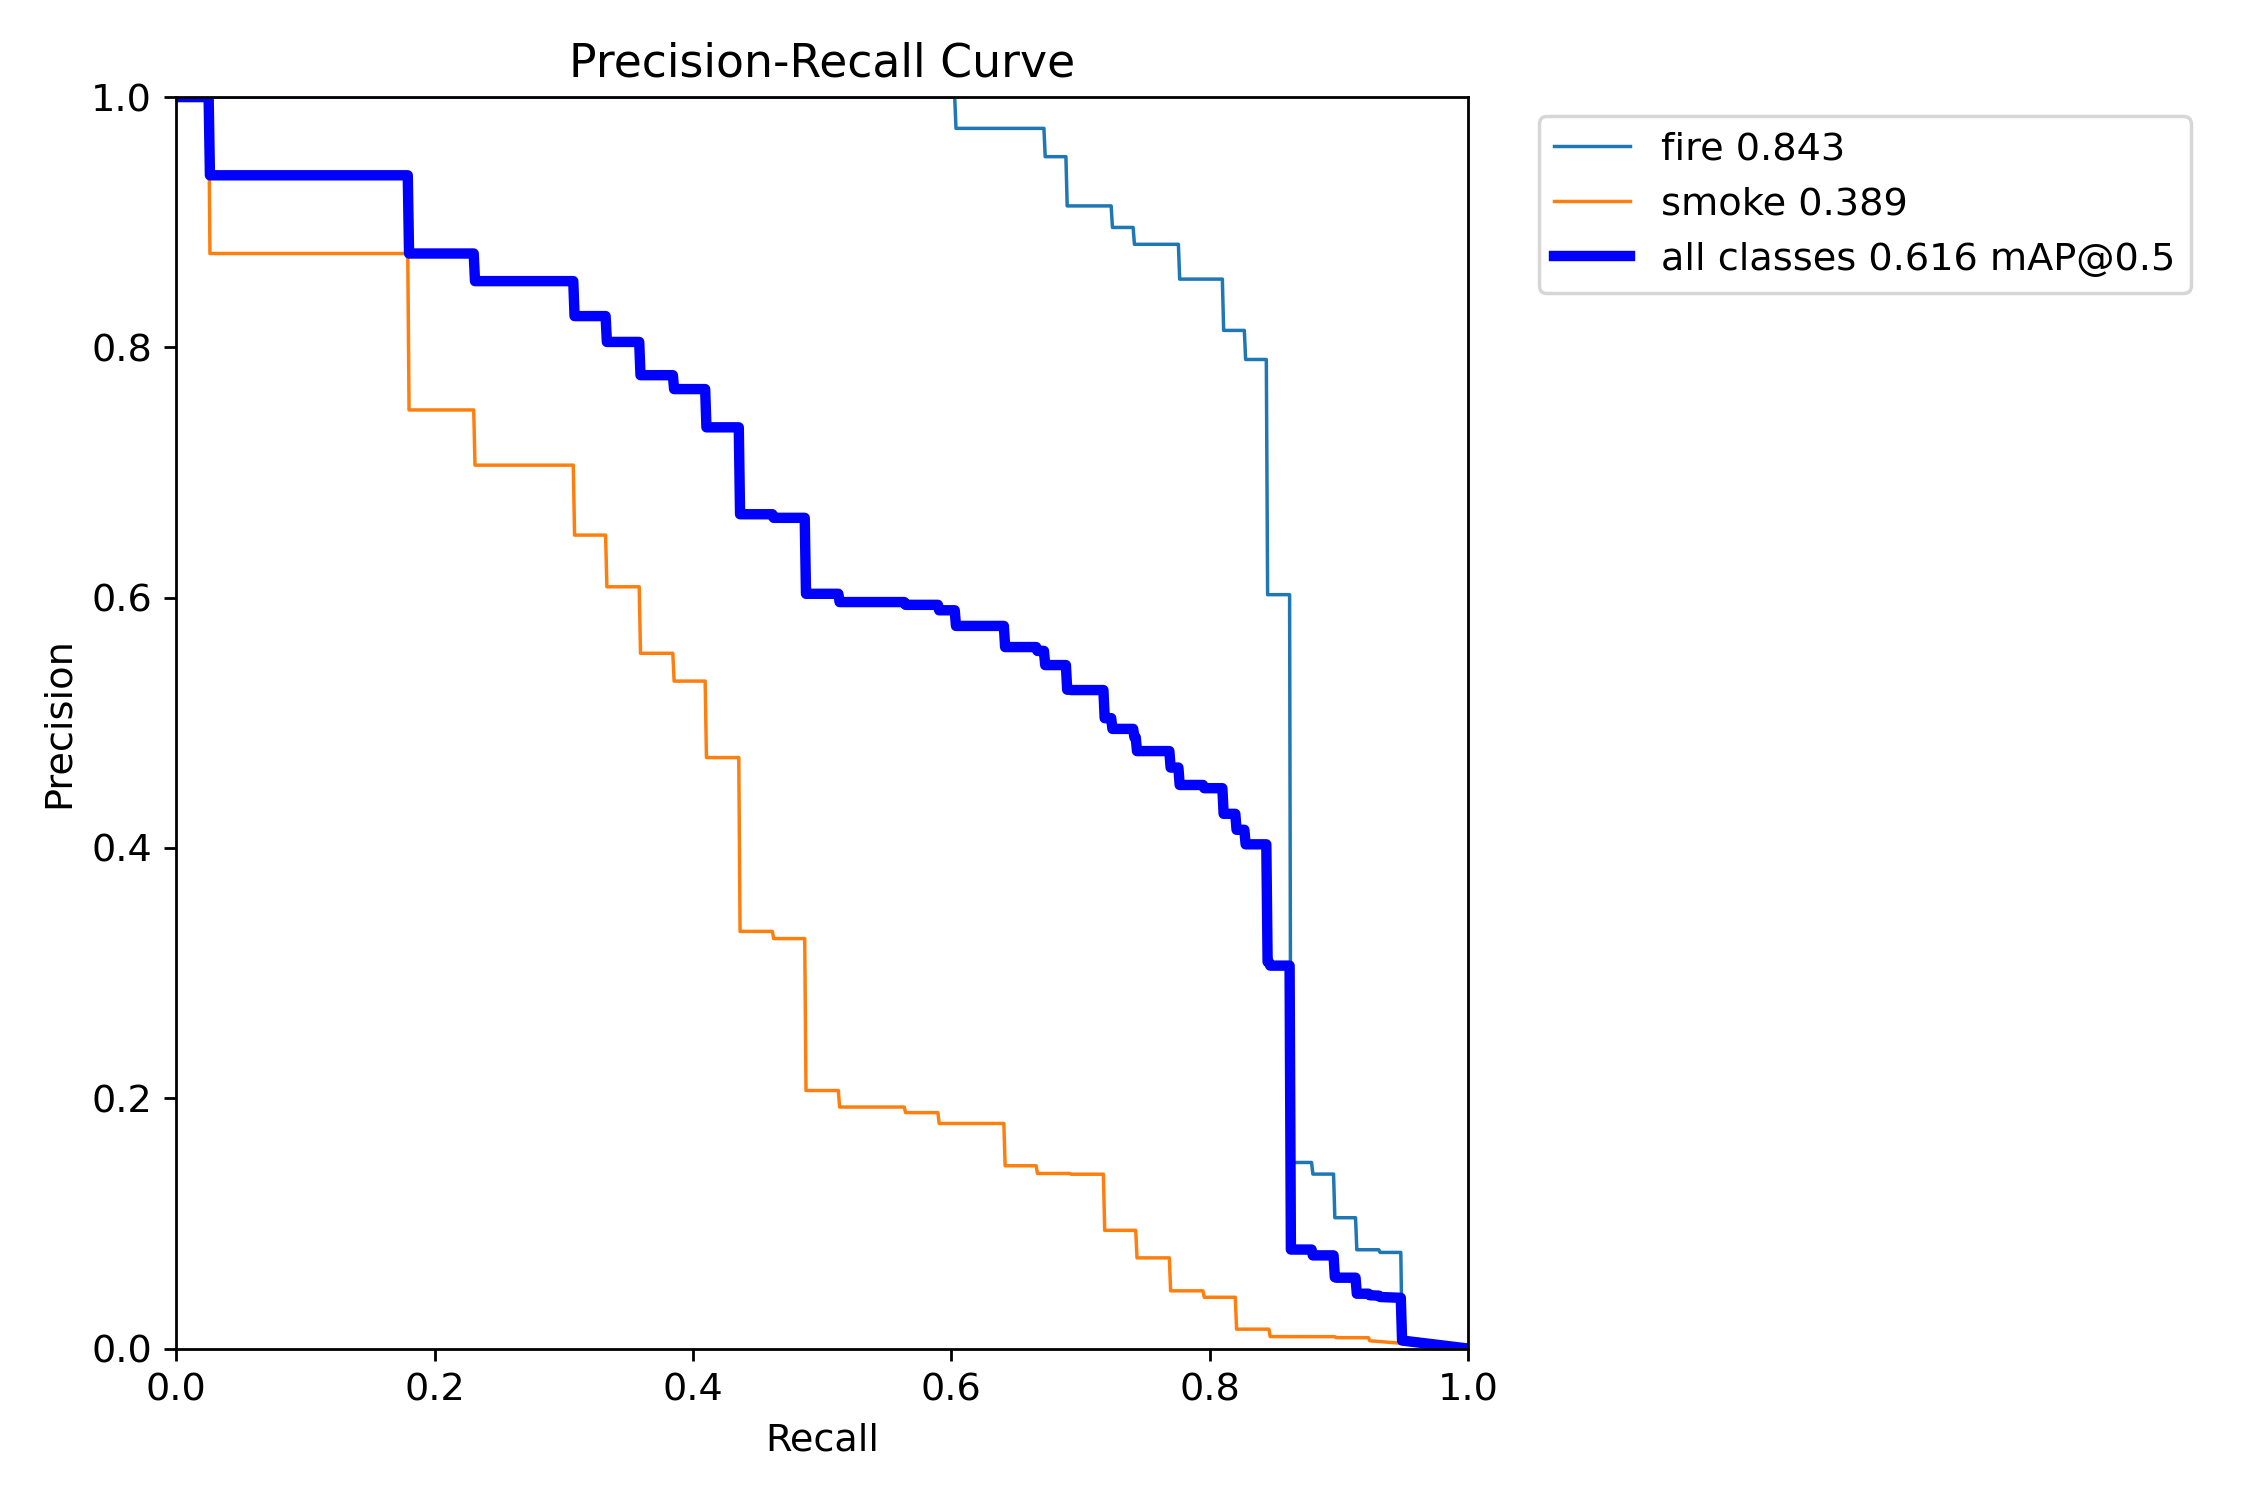

In [15]:
from IPython.display import Image, display

display(Image('/content/drive/MyDrive/runs/detect/train9/PR_curve.png'))

in the following part we display a batch of images that shows the prediction of the model on the validation dataset, that explains also the low value of mAP for detecting smoke.

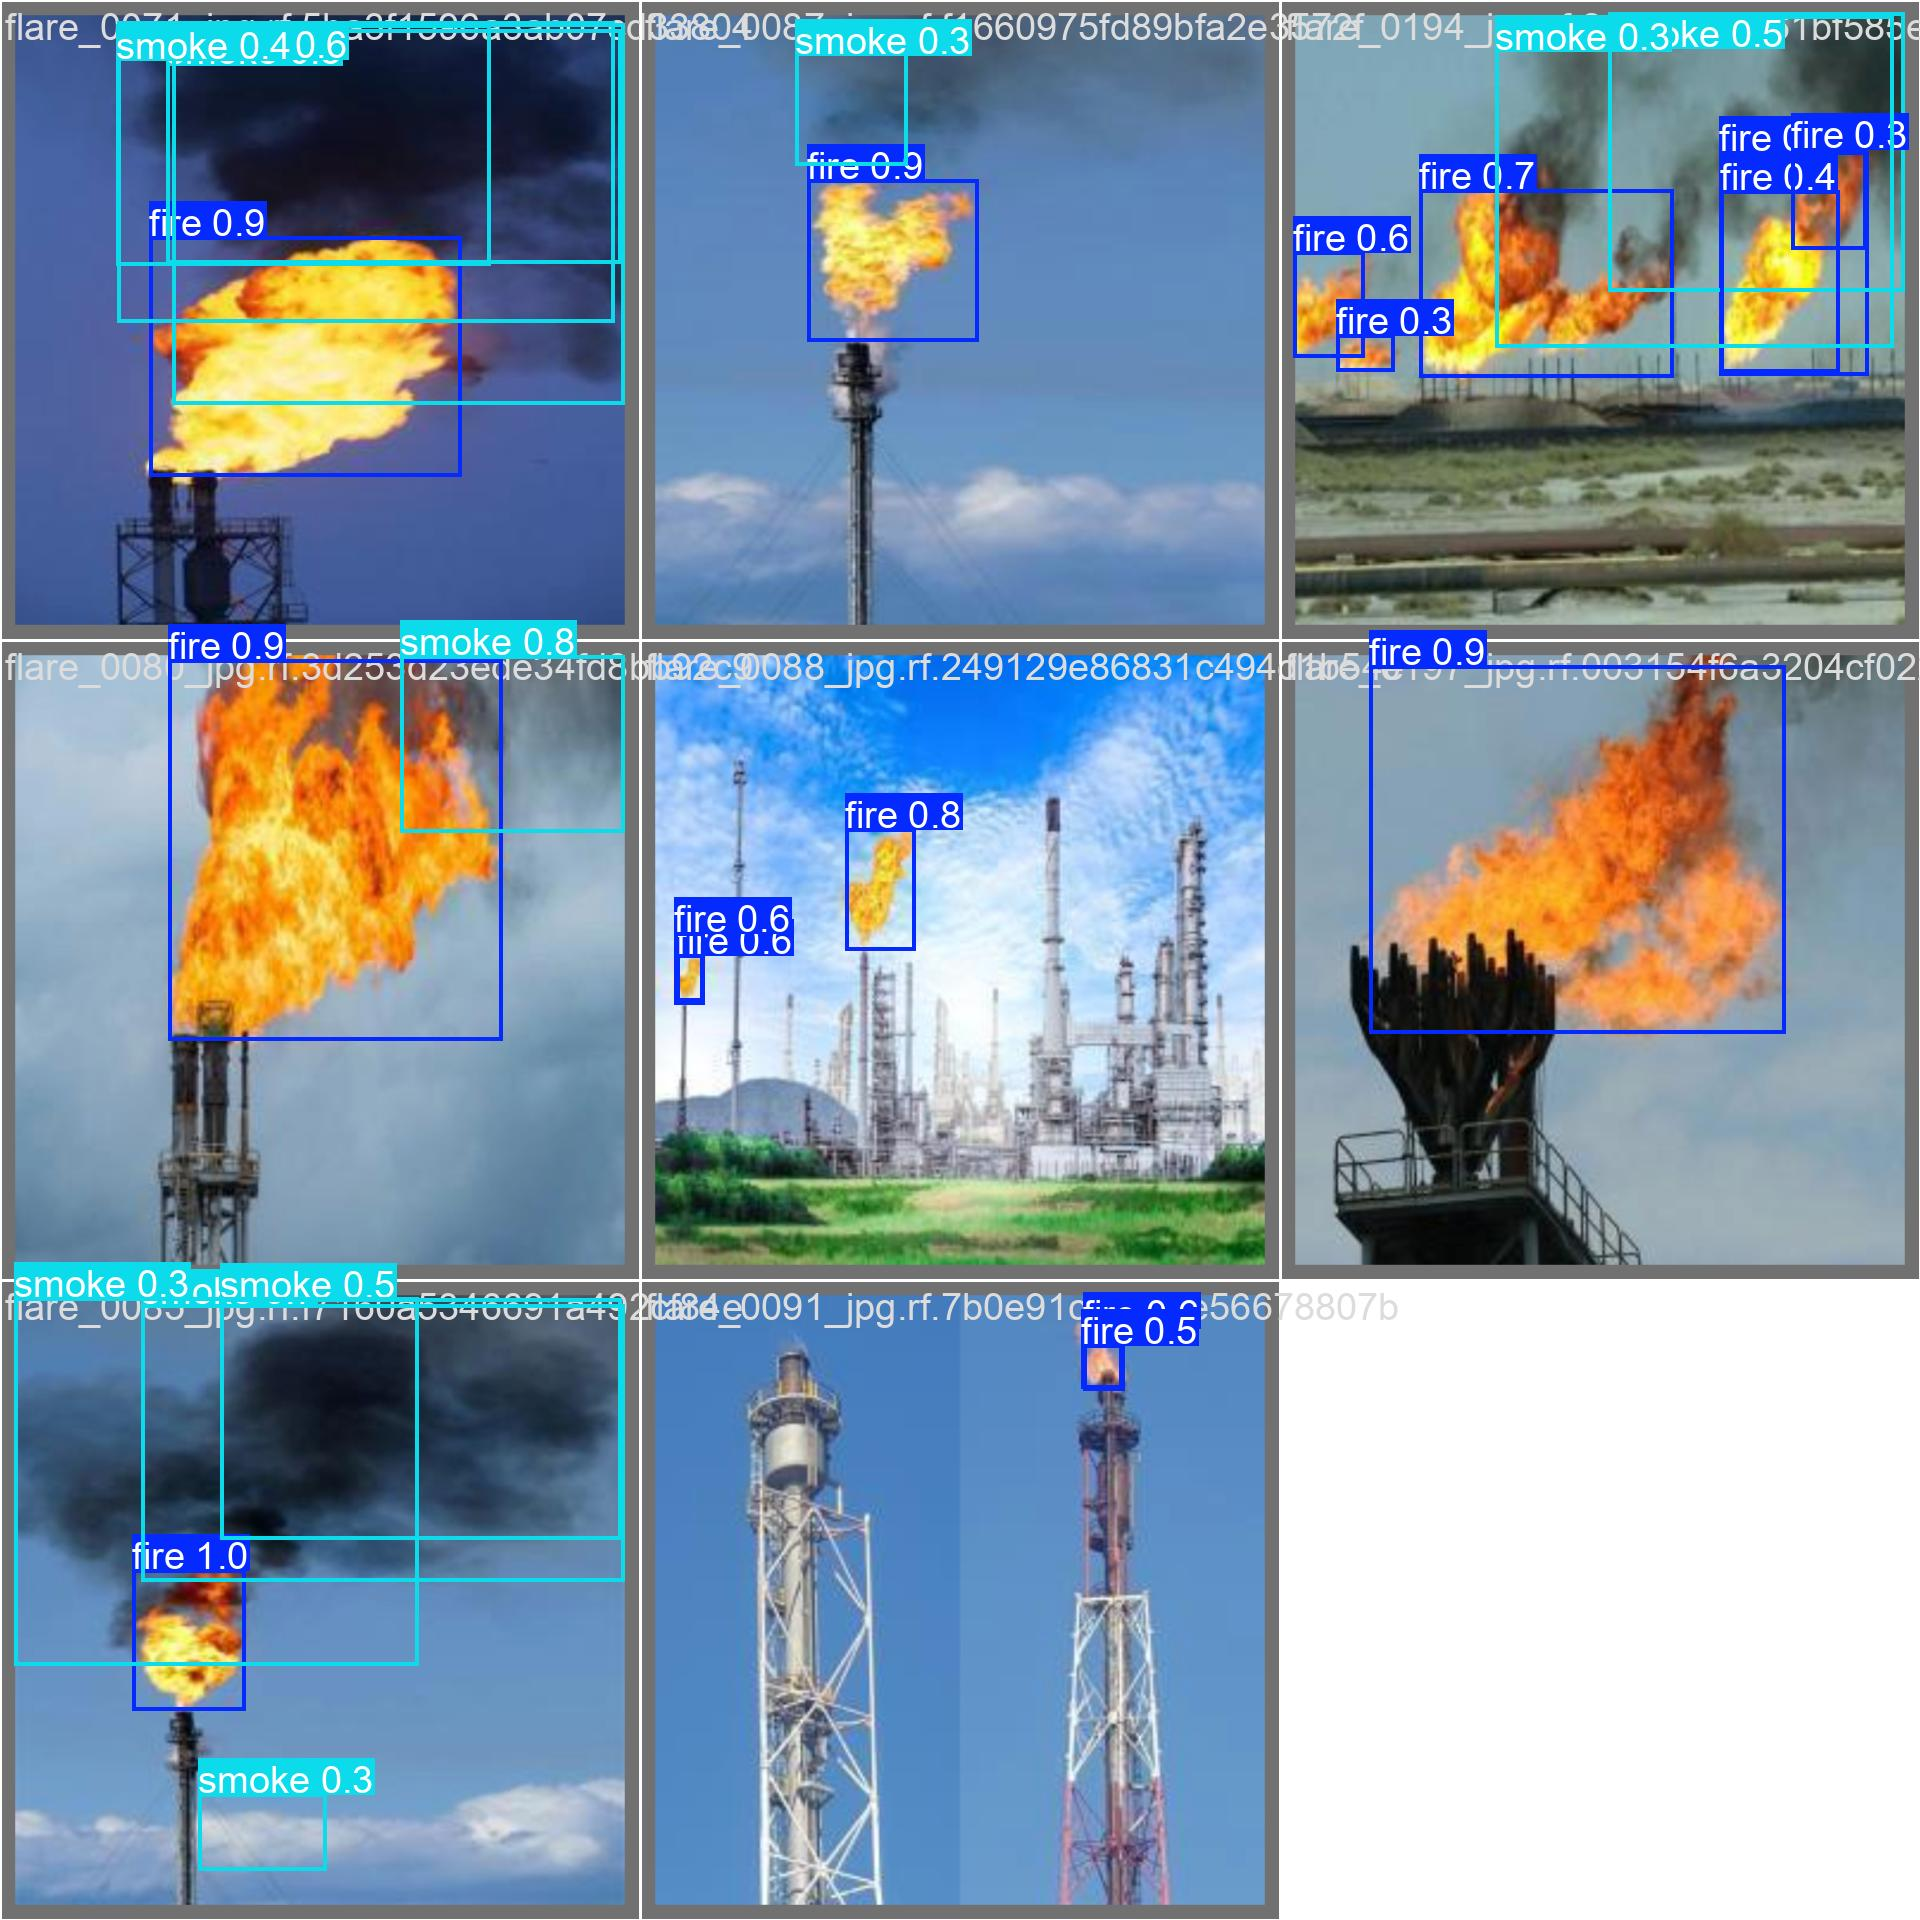

In [ ]:
from IPython.display import Image, display

display(Image('/content/drive/MyDrive/runs/detect/train9/val_batch2_pred.jpg'))